Description: Implementación y análisis del algoritmo SARSA Semi-gradiente episódico utilizando aproximación de funciones mediante Redes Neuronales Artificiales (PyTorch) para resolver el aterrizaje de un módulo lunar en LunarLander-v3.

In [4]:
# @title Instalación e importación de librerías
# !pip install "gymnasium[box2d]" torch numpy matplotlib tqdm

import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

# Garantizamos reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Experimento

El experimento evalúa el rendimiento de un agente que utiliza el algoritmo on-policy SARSA Semi-gradiente para aprender a aterrizar el módulo lunar.Este entorno consta de:
Espacio de estados: Vector continuo de 8 dimensiones (coordenadas x/y, velocidades x/y, ángulo, velocidad angular, y contacto de las dos patas).
Espacio de acciones: 4 acciones discretas (0: nada, 1: motor izquierdo, 2: motor principal, 3: motor derecho).
Recompensa: Recompensas densas basadas en la distancia a la plataforma, velocidad, inclinación, uso de combustible y un premio/castigo final de +100/-100 por aterrizar o estrellarse. El entorno se considera "resuelto" si se alcanzan 200 puntos.

Objetivo del experimento:
Implementar la parametrización de la función de valor de acción $\hat{q}(s, a, \mathbf{w})$ mediante una red neuronal profunda.
Implementar el bucle de control de SARSA utilizando la propagación hacia atrás (backpropagation) para aproximar el gradiente $\nabla \hat{q}(S, A, \mathbf{w})$.
Analizar la curva de aprendizaje y la estabilidad del entrenamiento puro on-line sin buffer de repetición.

Arquitectura de la Red Neuronal y PolíticaA diferencia de los métodos tabulares, aquí los pesos $\mathbf{w}$ son los parámetros de la red neuronal.

In [5]:
# @title Definición de la Red Neuronal y el Agente SARSA

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(QNetwork, self).__init__()
        # Red neuronal de 3 capas densas
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)  # Salida lineal para los valores Q

class SemiGradientSarsaAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        
        self.q_network = QNetwork(state_dim, action_dim)
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def get_action(self, state):
        # Política epsilon-greedy
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_dim)
        
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        return torch.argmax(q_values).item()

    def update(self, state, action, reward, next_state, next_action, done):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0)
        reward_tensor = torch.FloatTensor([reward])
        
        # 1. Calculamos q(S, A, w)
        q_values = self.q_network(state_tensor)
        q_sa = q_values[0][action]
        
        # 2. Calculamos el objetivo (Target): R + gamma * q(S', A', w)
        with torch.no_grad():
            if done:
                target = reward_tensor
            else:
                next_q_values = self.q_network(next_state_tensor)
                next_q_sa = next_q_values[0][next_action]
                target = reward_tensor + self.gamma * next_q_sa
                
        # 3. Calculamos la pérdida y actualizamos pesos (Descenso de gradiente)
        loss = self.loss_fn(q_sa, target[0])
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss.item()

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [6]:
# @title Bucle de Entrenamiento SARSA Semi-gradiente

def train_sarsa_lunar_lander(episodes=1000):
    env = gym.make("LunarLander-v3")
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    
    agent = SemiGradientSarsaAgent(state_dim, action_dim, lr=5e-4)
    
    rewards_history = []
    
    for ep in tqdm(range(episodes)):
        state, _ = env.reset()
        action = agent.get_action(state)  # A
        
        total_reward = 0
        done = False
        
        while not done:
            # Tomar acción A, observar R, S'
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Elegir A' desde S' usando la política actual
            next_action = agent.get_action(next_state)
            
            # Actualizar pesos: w <- w + alpha * [R + gamma*q(S',A') - q(S,A)] * grad(q)
            agent.update(state, action, reward, next_state, next_action, done)
            
            state = next_state
            action = next_action
            total_reward += reward
            
        agent.decay_epsilon()
        rewards_history.append(total_reward)
        
    env.close()
    return rewards_history, agent

# Ejecutar el entrenamiento
rewards, trained_agent = train_sarsa_lunar_lander(episodes=1500)

c:\Users\aaron\miniconda3\envs\dlpln\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
100%|██████████| 1500/1500 [19:35<00:00,  1.28it/s]


Análisis de Resultados y ConclusionesRecompensa promedio por episodio:Al inicio, el agente obtendrá puntuaciones cercanas a -200 o -300, ya que los motores se activan aleatoriamente y el módulo se estrella rápidamente o sale de la pantalla. A medida que $\epsilon$ decae y los pesos $\mathbf{w}$ se ajustan, la recompensa media ascenderá.El desafío técnico del SARSA Semi-gradiente en Deep RL:Si observas mucha inestabilidad (gráficas de recompensa que suben a 100 y de repente caen en picado a -200), no es un error en tu código, sino una característica matemática de usar Redes Neuronales con métodos on-line puros como SARSA.Correlación temporal: Las muestras sucesivas $(S, A, R, S')$ están altamente correlacionadas, lo que hace que la red neuronal "olvide" lo aprendido en zonas anteriores del espacio de estados (catastrophic forgetting).Objetivos móviles: Estás actualizando la red usando predicciones de la misma red en constante cambio.Conclusión respecto a Q-Learning tabular (Taxi-v3):Mientras que en problemas tabulares SARSA y Q-Learning convergen con garantías sólidas, al introducir Redes Neuronales el control del hiperparámetro de tasa de aprendizaje ($\alpha$) y la arquitectura de la red dictan el éxito. Aunque SARSA Semi-gradiente demuestra el principio de la parametrización de funciones, en la práctica profesional para LunarLander se suele dar un paso evolutivo más hacia DQN (Deep Q-Networks), que añade un "Buffer de Repetición" para romper la correlación y una "Red Objetivo" (Target Network) para estabilizar el gradiente.

In [7]:
# Guardar pesos del modelo entrenado
torch.save(trained_agent.q_network.state_dict(), "sarsa_lunarlander_qnetwork.pth")
print("Pesos guardados correctamente.")

Pesos guardados correctamente.


In [8]:
def greedy_action(q_network, state):
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        q_values = q_network(state_tensor)
        action = torch.argmax(q_values).item()
    return action

In [9]:
def run_episode_greedy_lunarlander(env, q_network, max_steps=1000):
    frames = []
    state, _ = env.reset()
    
    for _ in range(max_steps):
        frame = env.render()
        frames.append(frame)

        action = greedy_action(q_network, state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        state = next_state
        
        if terminated or truncated:
            frames.append(env.render())
            break

    return frames

In [10]:
import imageio

def frames_to_gif(frames, filename="lunarlander_sarsa.gif"):
    with imageio.get_writer(filename, mode='I') as writer:
        for frame in frames:
            writer.append_data(frame)
    return filename

In [11]:
import base64
from IPython.display import HTML

def display_gif(gif_path):
    with open(gif_path, 'rb') as f:
        video = f.read()
    b64 = base64.b64encode(video)
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" />')

GIF guardado en: lunarlander_sarsa.gif



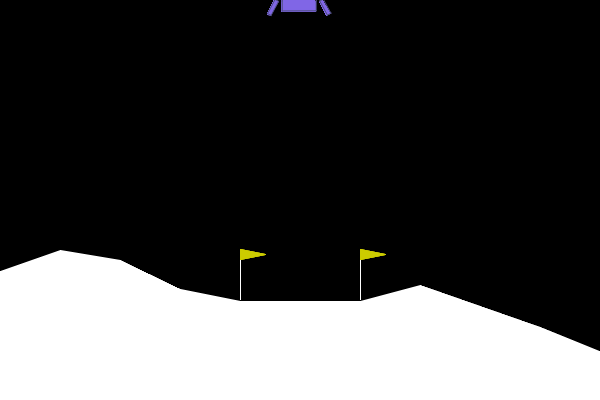

In [12]:
# Crear entorno con modo render para capturar imágenes
env_demo = gym.make("LunarLander-v3", render_mode='rgb_array')

state_dim = env_demo.observation_space.shape[0]
action_dim = env_demo.action_space.n

# Instanciar red con misma arquitectura
q_net_loaded = QNetwork(state_dim, action_dim, hidden_dim=128)

# Cargar pesos
q_net_loaded.load_state_dict(torch.load("sarsa_lunarlander_qnetwork.pth"))
q_net_loaded.eval()

# Ejecutar episodio greedy
frames = run_episode_greedy_lunarlander(env_demo, q_net_loaded)

env_demo.close()

# Crear GIF
gif_path = frames_to_gif(frames, filename="lunarlander_sarsa.gif")
print("GIF guardado en:", gif_path)

# Mostrar GIF
display_gif(gif_path)